# Analysis of results

This notebook explores in different ways, the data selected by the pipeline/vetting process. It should be run only after notebook *results.ipynb* was run, and created file *candidates_best.fits*.

- plots transient locations in their image's FOVs.
- compares parameters from PSF analysis in between the transient's data and normal stars.
- plots visual summary of transients.

At this time, results reported here come from all plate pairs that share common FOVs on the sky, taken at the same night, by the Großer Schmidtspiegel 1.2-m Schmidt camera at Hamburg Observatory between Feb 1955 and Aug 1957 (106 plates in total).

In [1]:
import os
import warnings
import json
from collections import OrderedDict

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.pyplot import imshow
from matplotlib.colors import LogNorm

from astropy.io import fits
from astropy.wcs import WCS, FITSFixedWarning
from astropy.table import Table
from astropy.coordinates import SkyCoord

import pandas as pd

import settings
from library import plot_psf_analysis, plot_cutout_series, update_dataset, get_par, get_cutouts
from settings import RESULTS, current_dataset, fname

In [2]:
warnings.filterwarnings('ignore', category=FITSFixedWarning)

In [3]:
# Image names are not imported, but kept instead in a json file
images_json = 'images.json'
try:
    json_file = open(images_json, 'r')
    images = json.load(json_file)
except FileNotFoundError:
    print(f"Error: File {images_json} was not found.")
except json.JSONDecodeError as e:
    print(f"JSON Error: {e}")

In [4]:
table_transients = Table.read(os.path.join(RESULTS, "candidates_best.fits"), format='fits')

In [5]:
# table_transients

## Multi-transient plate pairs

In here, we search for plates with multiple transients.

In [6]:
# count how many transients are in each plate
counter = OrderedDict()
for row in range(len(table_transients)):
    plate_id = table_transients['plate_id_1'][row]
    if plate_id in list(counter.keys()):
        counter[plate_id] += 1
    else:
        counter[plate_id] = 1
        
# prune out plates with no transient
for k in list(counter.keys()):
    if counter[k] < 1:
        del counter[k] 
        
counter

OrderedDict([(9246, 4),
             (9319, 1),
             (9322, 1),
             (9533, 1),
             (9545, 1),
             (9012, 2),
             (9016, 1),
             (9095, 25),
             (9099, 15),
             (9174, 1),
             (9228, 2),
             (9233, 7),
             (9285, 2),
             (9337, 1),
             (9528, 1),
             (9548, 1)])

Out of a total of 79 plates, of which 50 have a "next plate" that enables searching for transients, we find 16 with transients. Half of those have more than one transient, up to 25 transients in plate 9095.

The 9 sequences with more than 2 plates didn't yeld any "followup" trasients in the same sequence. That is, each sequence has only one plate with transients, and nothing before or after said plate. 

For each plate in dict above, we create a plot of the transients within the FOV.

In [7]:
def plot_frame(plate_id, transients):

    # isolate rows for selected plate
    mask = transients['plate_id_1'] == plate_id
    table_plate = transients[mask]
    
    seq_key = table_plate['seq'][0]

#     print(table_plate['source_id'])
    
    # retrieve information from plate
    json_file = open('images.json', 'r')
    images = json.load(json_file)
    image_name = images[str(plate_id)]
    header = fits.getheader(fname(image_name))
    date = header['DATE-AVG']
    wcs = WCS(header)
    naxis1 = header['NAXIS1']
    naxis2 = header['NAXIS2']

    fig = plt.figure(figsize=(4, 4))
    ax = fig.add_subplot(1, 1, 1, projection=wcs)
    
    # plot frame
    x_corners = [0, naxis1, naxis1, 0, 0]
    y_corners = [0, 0, naxis2, naxis2, 0]
    world_corners = wcs.pixel_to_world(x_corners, y_corners)
    ax.plot(world_corners.ra.deg, world_corners.dec.deg, 
        transform=ax.get_transform('world'), color='gray', linewidth=1)

    # plot transient locations
    for row in range(len(table_plate)):
        ra  = table_plate['ra_icrs'][row]
        dec = table_plate['dec_icrs'][row]

        ax.scatter(ra, dec, transform=ax.get_transform('world'), marker='o', s=20, 
                   edgecolor='red', facecolor='red')
        
#         print(table_plate['ra_icrs'][row], table_plate['dec_icrs'][row], table_plate['x_source'][row], table_plate['y_source'][row])

    ax.set_xlabel('R.A')
    ax.set_ylabel('Dec.')
    ax.grid(color='gray', ls='solid', linewidth=1)
    plt.title('Plate ID: ' + str(plate_id) + "  file: " + image_name + "  " + seq_key + "  " + date)
    plt.tight_layout()

    plt.show()

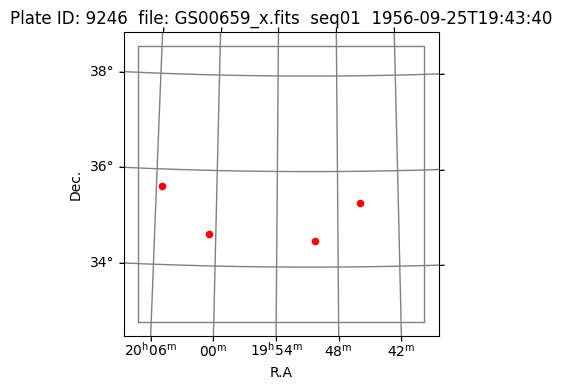

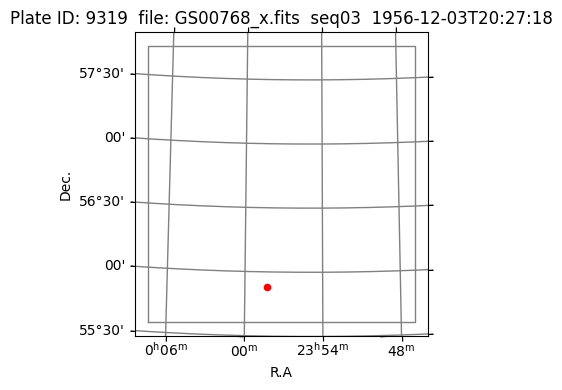

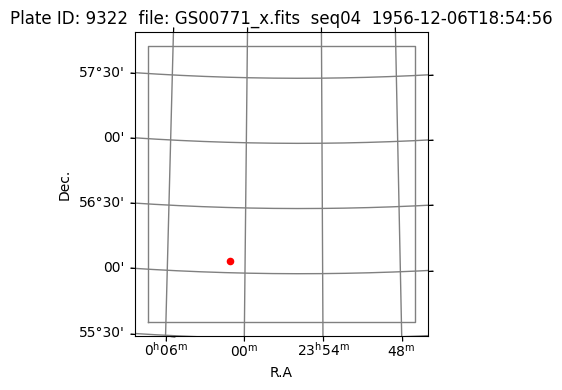

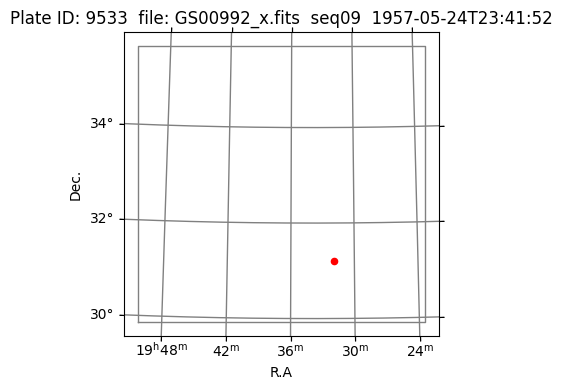

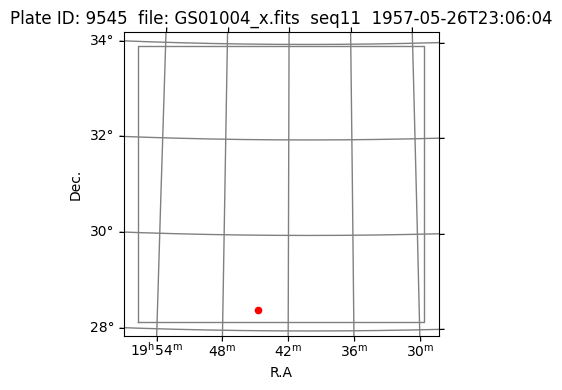

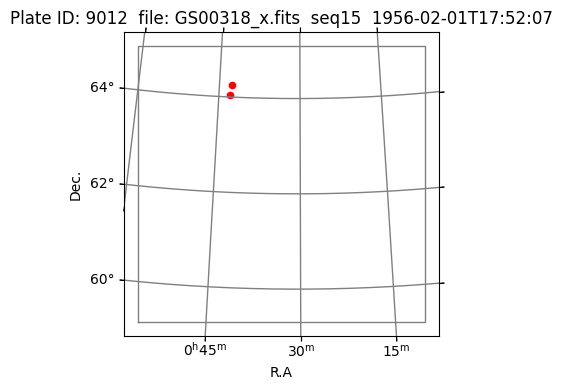

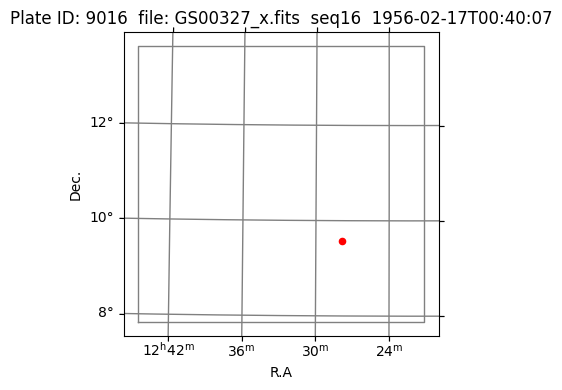

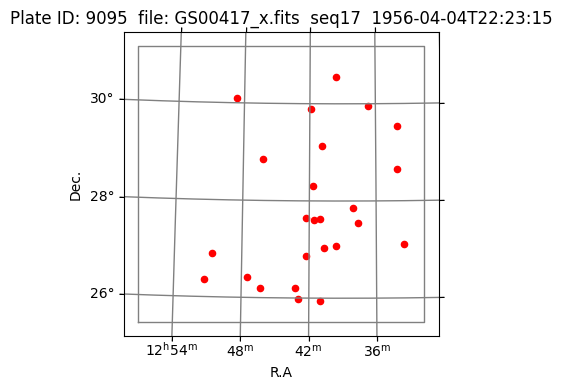

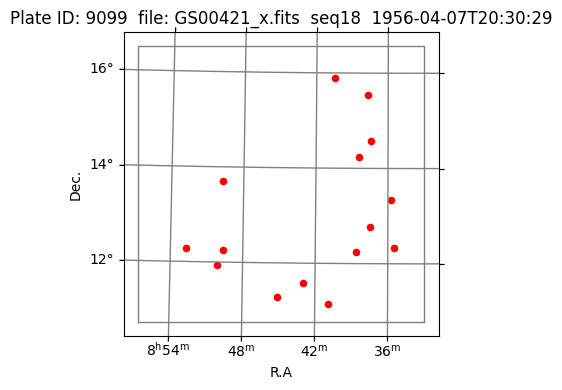

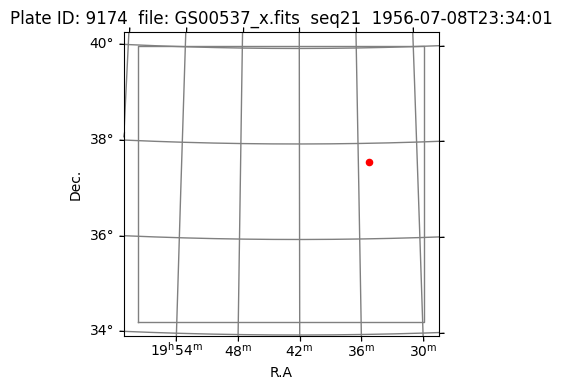

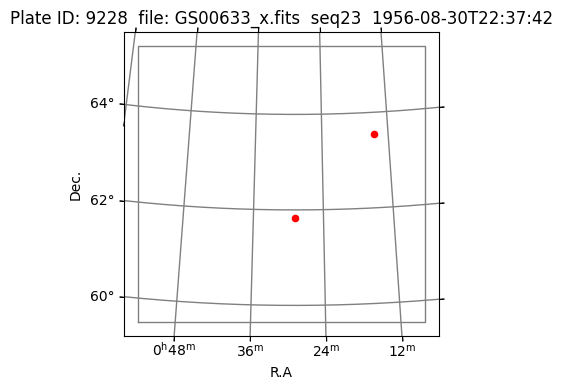

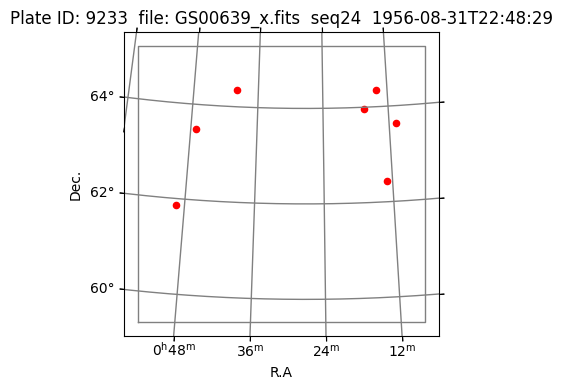

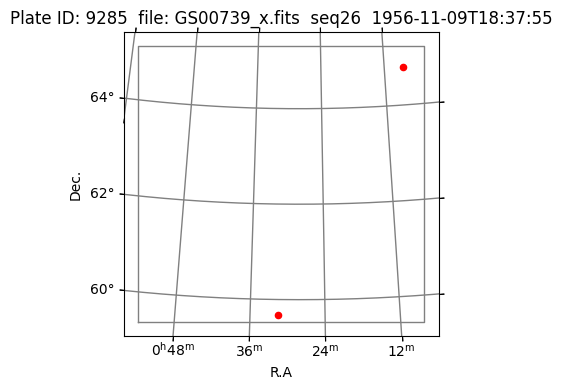

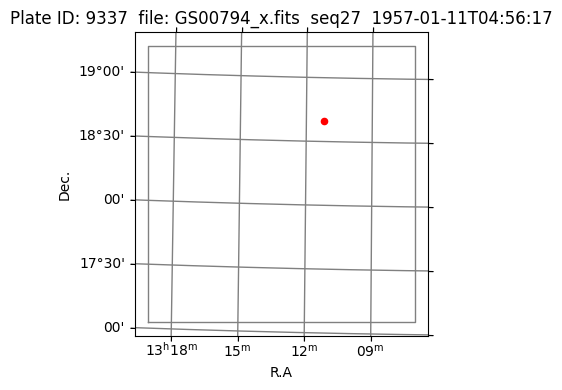

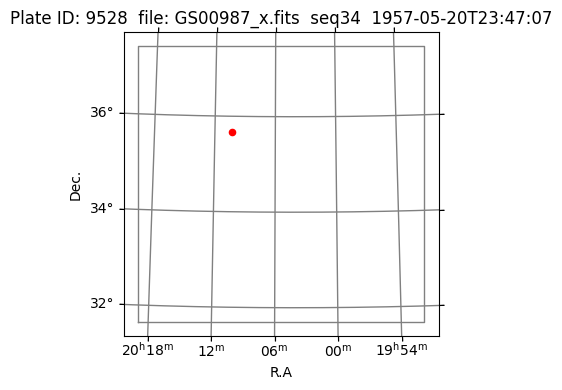

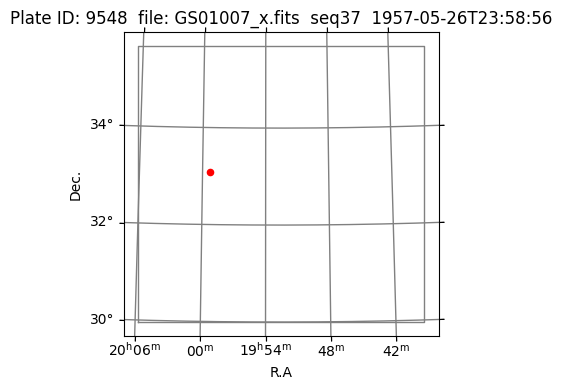

In [8]:
for plate_id in list(counter.keys()):
    plot_frame(plate_id, table_transients)

The 3 plates with a lot of transients lead me to suspect that they could be in fact artifacts that still elude detection. A visual and detailed exam of each one is warranted. 

Maybe artifacts caused by a bad batch of chemical developer/fixer, or a plate envelope that led to contamination by dust, or something in those lines. We should check dates against the "atomic bomb hypothesis", and the "UFO sightings hypothesis" just in case. And maybe search for more information about these plates' origins and history.

Another avenue worth pursuing is to try to correlate with VASCO data and findings for these dates (if any).

## PSF

We want to compare each transient's FWHM (and other parameters) with the same parameters from a sample of stars *from the same plate as the transient*. Looking for any systematic effect that could inform about the nature of the transients.

Code below displays these parameters (as a function of peak flux):

- ***FWHM***: width of Gaussian fit to the object.

- ***elongation***: sextractor-produced ratio between major and minor axis of ellipse fit to the object.

- ***qfit***: a quality-of-fit metric produced by the Gaussian fitting library, defined as the sum of the absolute value of the fit residuals divided by the fit flux. qfit is zero for sources that are perfectly fit by the PSF model.

- ***cfit***: a quality-of-fit metric produced by the Gaussian fitting library, defined as the fit residual (data - model) in the initial central pixel value divided by the fit flux. Large positive values indicate sources that are sharper than the PSF model (e.g., cosmic ray, hot pixel, etc.). Large negative values indicate sources that are broader than the PSF model

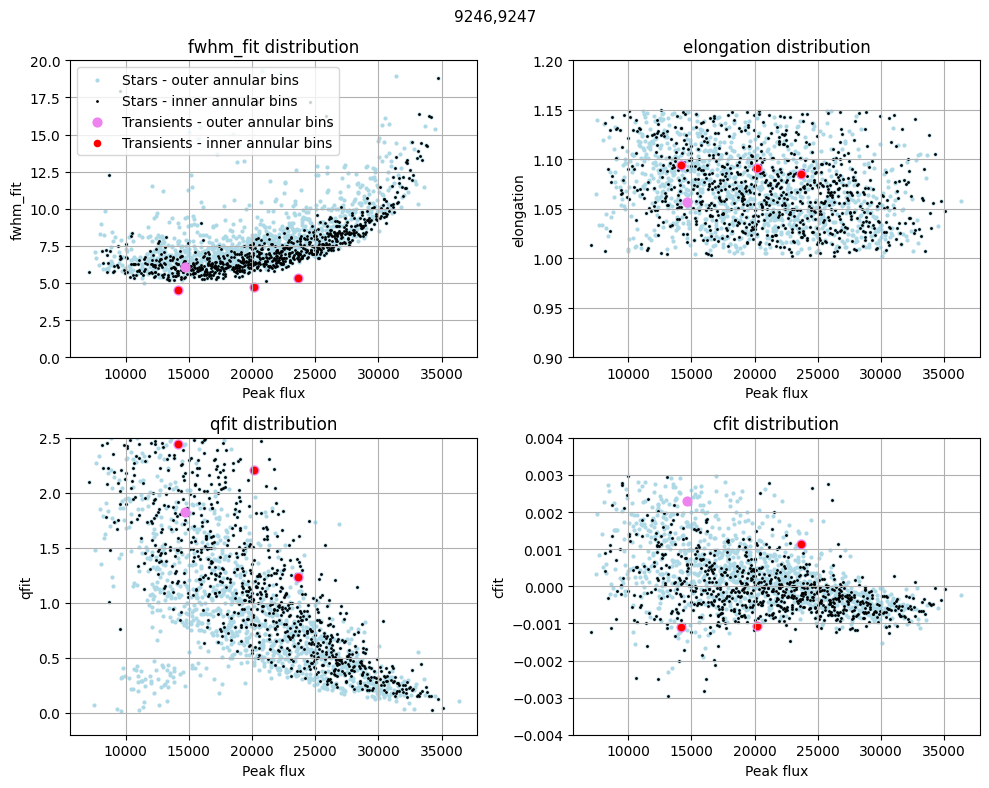

23660.53125 5.313001646706284 40348560131057
20167.43359375 4.715950707742909 40348560185546
14672.8720703125 6.0620453763863145 40348560212653
14155.5595703125 4.52905456471368 40348560141104




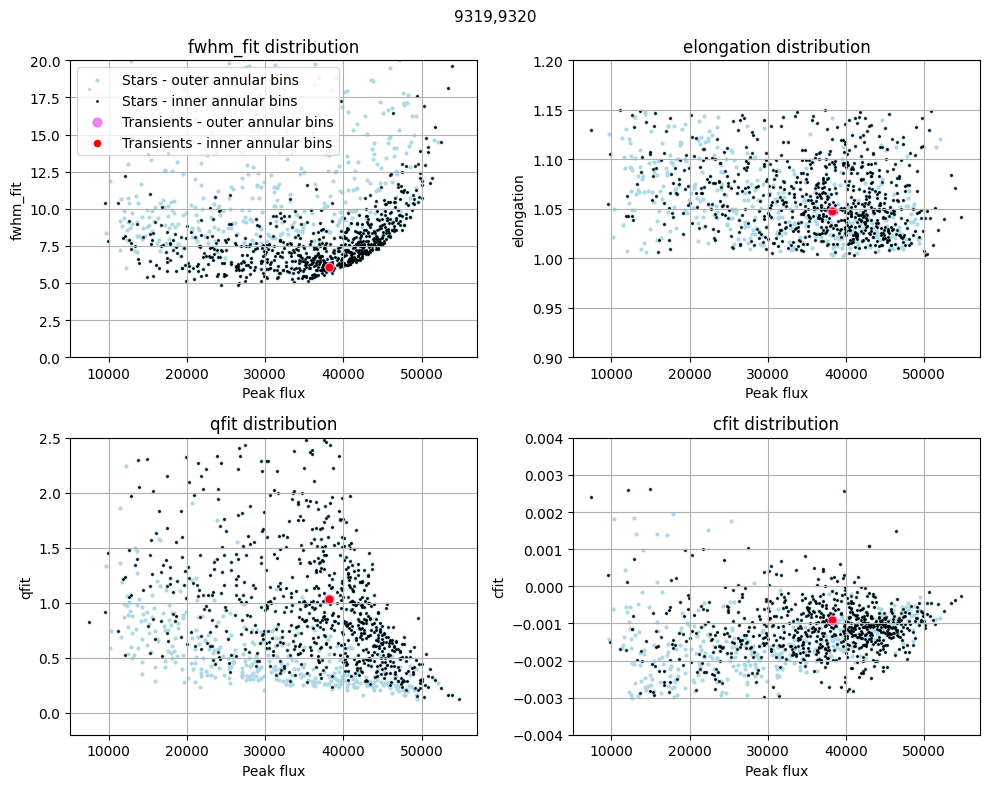

38214.90234375 6.095897145761215 40349380007658




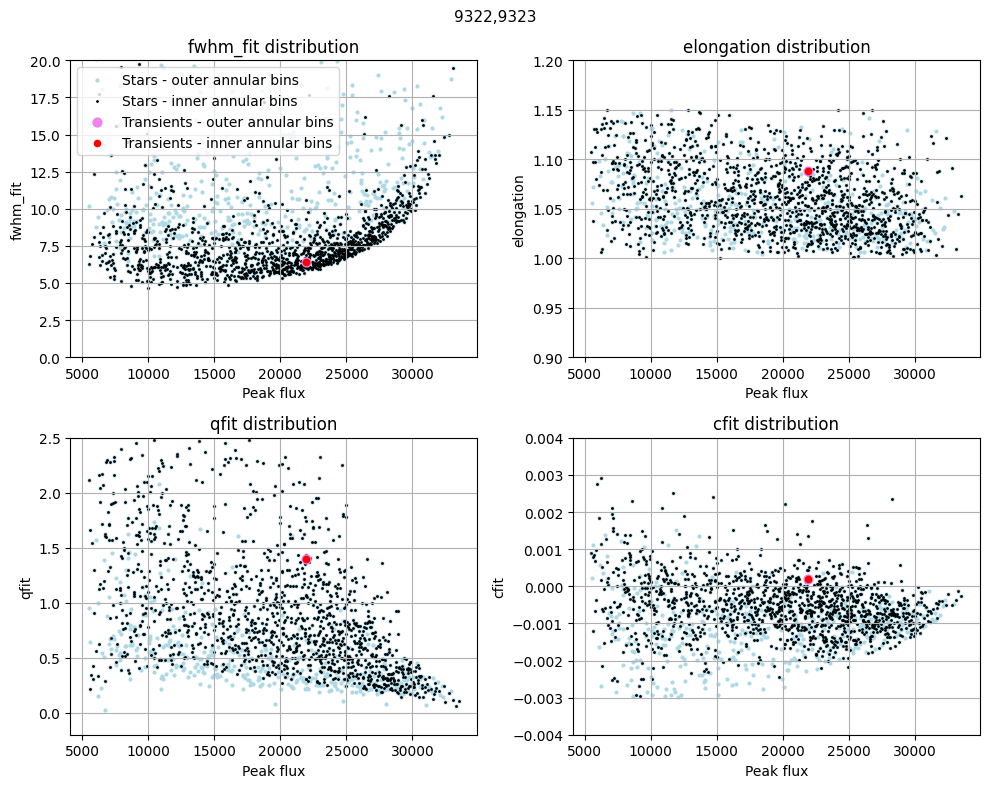

21930.33984375 6.4127765015406455 40349440012079




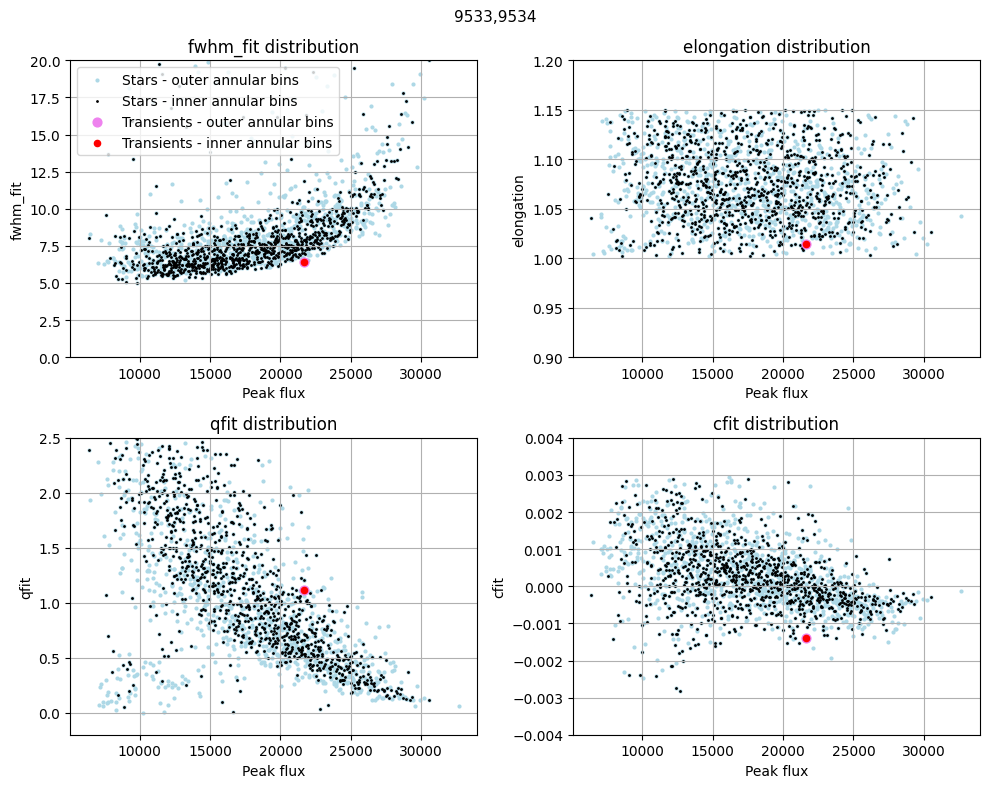

21641.64453125 6.4232591668968 40351330140141




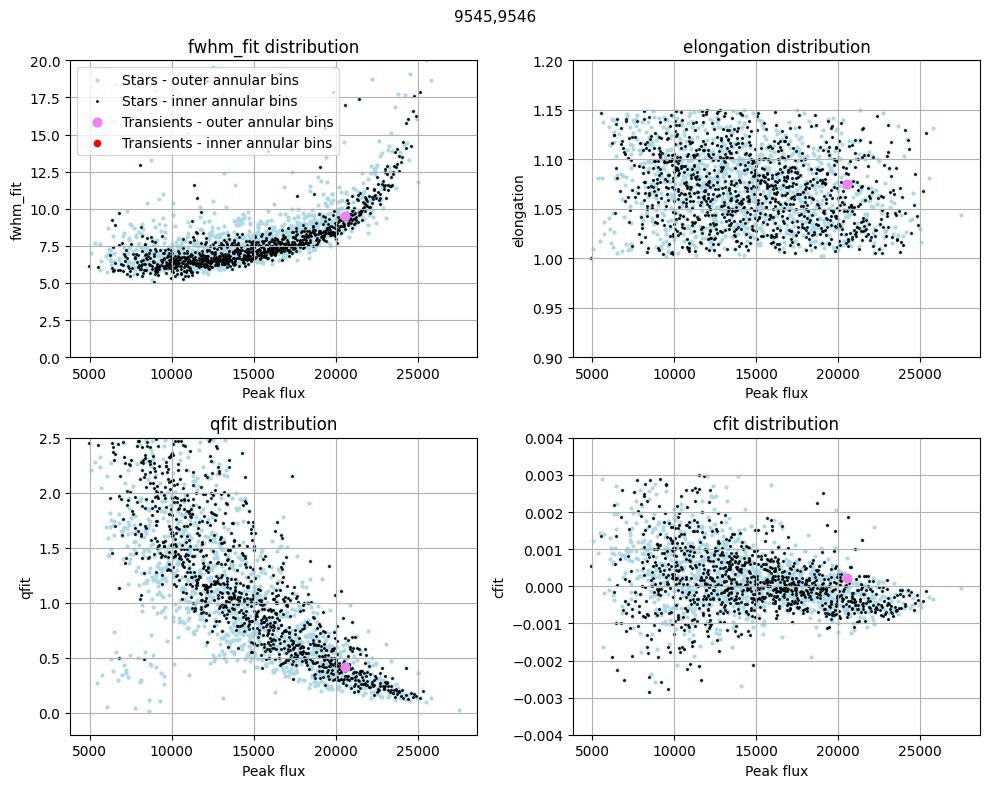

20546.19140625 9.508498742209987 40351520017054




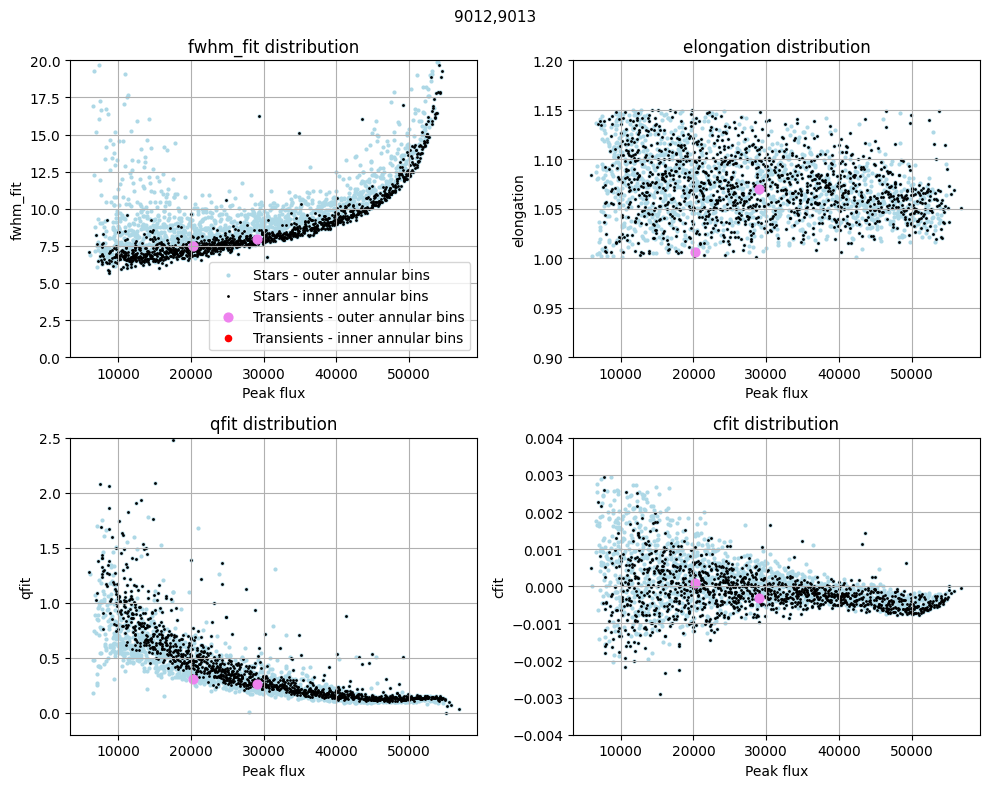

29045.740234375 7.950694897972605 40346700054403
20276.60546875 7.5104694044267735 40346700056383




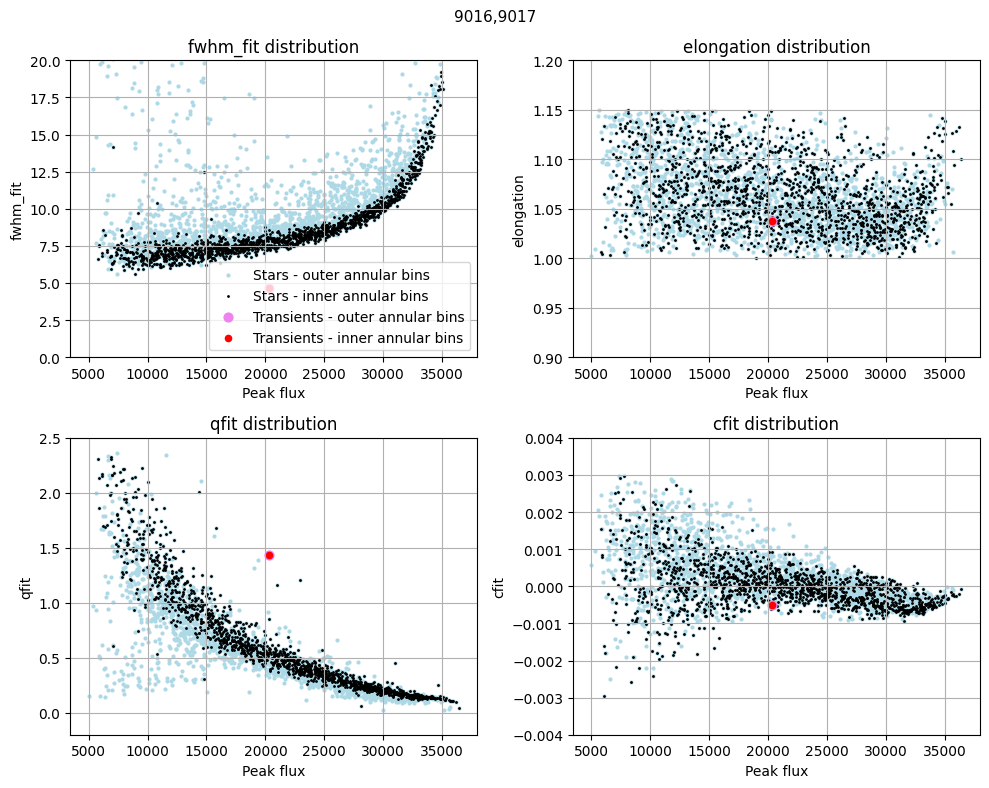

20333.59765625 4.656638793587514 40346780012245




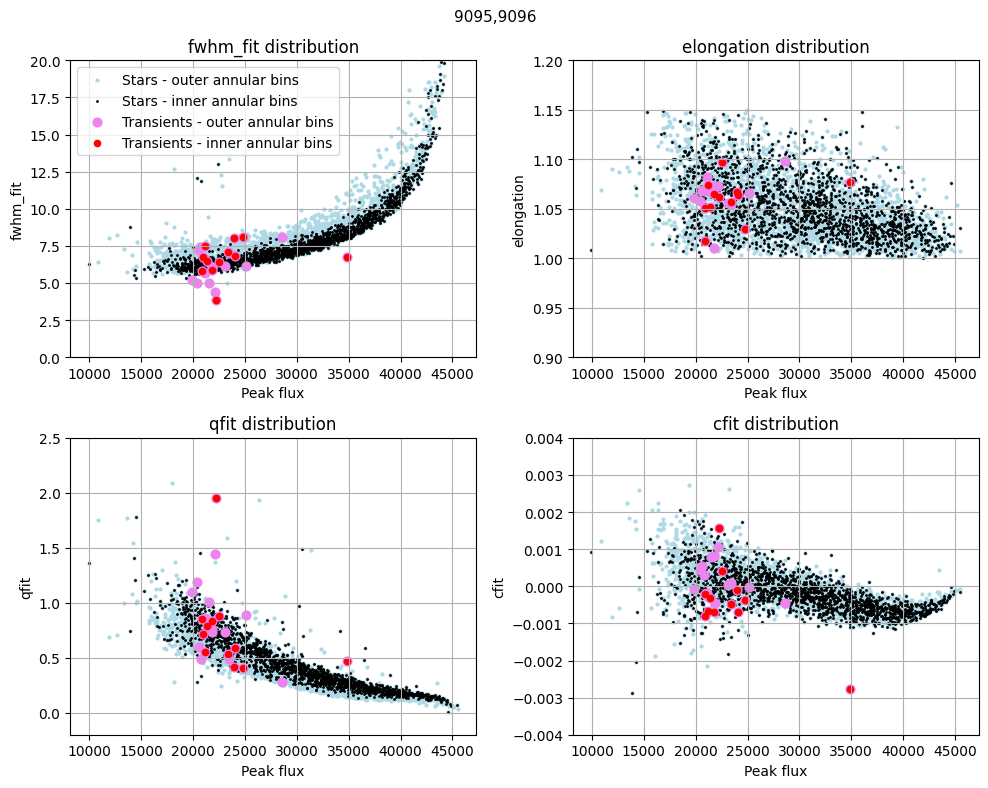

34863.43359375 6.724862581570136 40347080017951
28615.27734375 8.093367384411197 40347080013570
25097.2890625 6.14600652717669 40347080039830
24774.115234375 8.086185400187759 40347080018409
24053.453125 6.799952667528277 40347080018721
23974.603515625 8.058870900573014 40347080029335
23433.158203125 7.006452056147448 40347080031873
23358.728515625 7.073220717706505 40347080012953
23096.248046875 6.118216115784986 40347080008041
22539.40234375 6.399401979349692 40347080018531
22222.880859375 3.862952030568574 40347080034555
22103.970703125 4.4181292493099225 40347080035033
21854.310546875 6.092963091081892 40347080036412
21797.455078125 5.903987576410601 40347080014373
21773.619140625 6.101050853187831 40347080006319
21484.4375 5.00831002621197 40347080009365
21348.228515625 6.487717995139095 40347080014630
21163.5234375 7.499516927968763 40347080023887
21129.849609375 5.6700438853610615 40347080008013
20908.720703125 6.780077394367671 40347080027642
20874.02734375 5.83448978762008 403

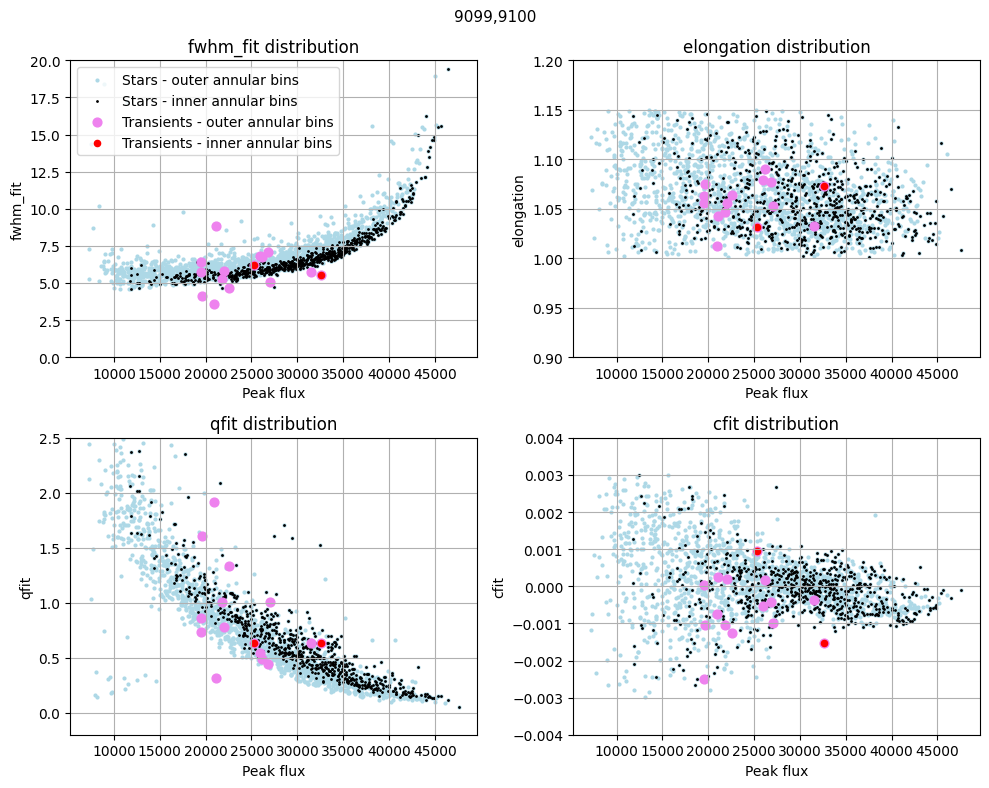

32589.69140625 5.572172170123504 40347160043802
31504.32421875 5.76128890161017 40347160024138
27018.12890625 5.099635654038302 40347160009515
26808.4765625 7.10197524223 40347160056784
26150.302734375 6.7182571068584025 40347160034420
25927.53515625 6.833442636787322 40347160023280
25272.92578125 6.211278490481175 40347160038529
22596.876953125 4.670944156369558 40347160028698
22020.46484375 5.789155719245988 40347160023829
21801.474609375 5.239074134286945 40347160011655
21099.0859375 8.806956468042317 40347160020302
20914.080078125 3.5589425692809087 40347160060262
19651.1953125 4.119100235350765 40347160015446
19498.6875 5.748814375476344 40347160046861
19484.9921875 6.381267855610851 40347160024335




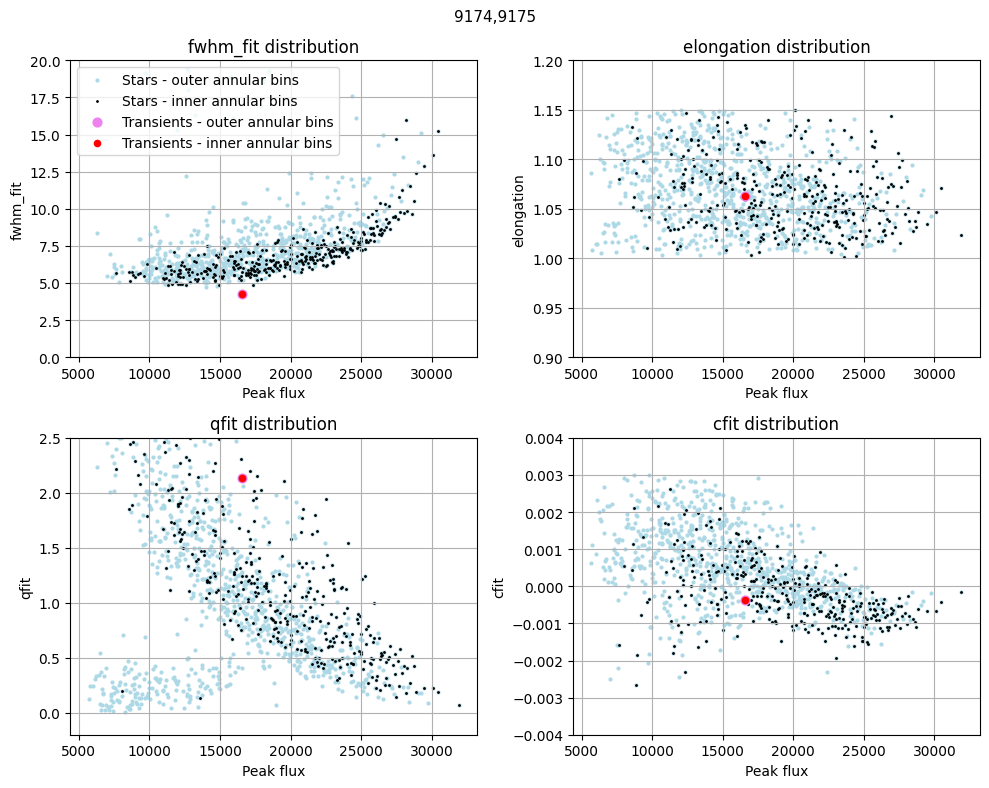

16565.484375 4.241224034844397 40347800283769




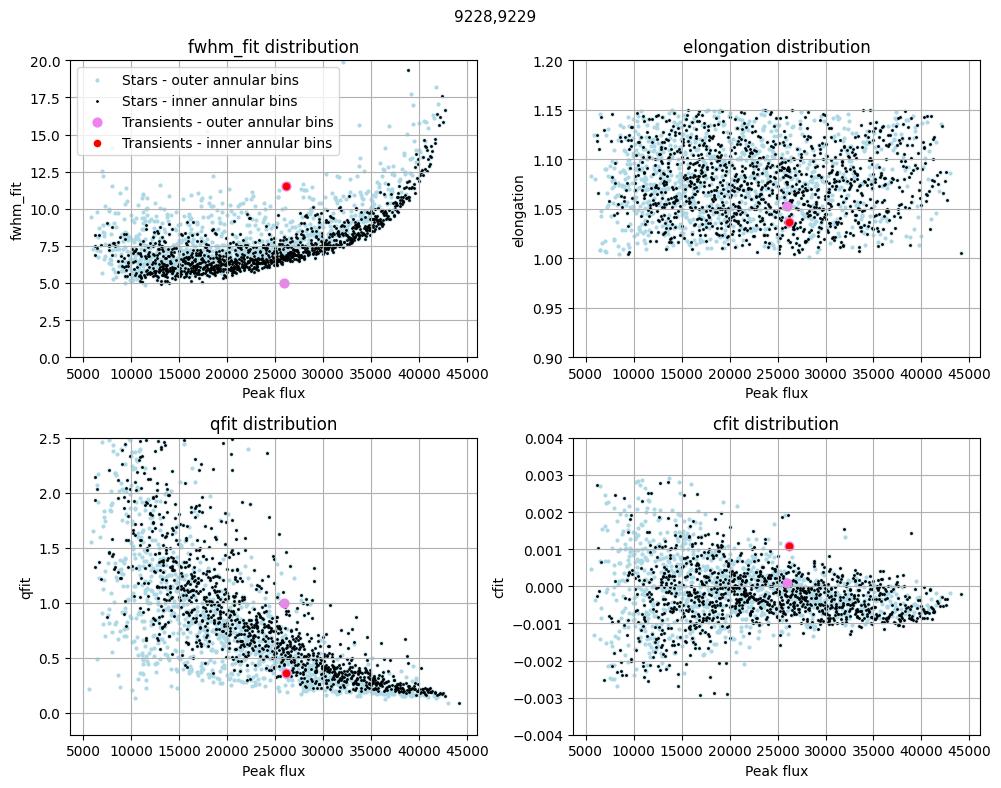

26203.40625 11.520446472306547 40348200090053
25975.87109375 5.032100559704795 40348200158428




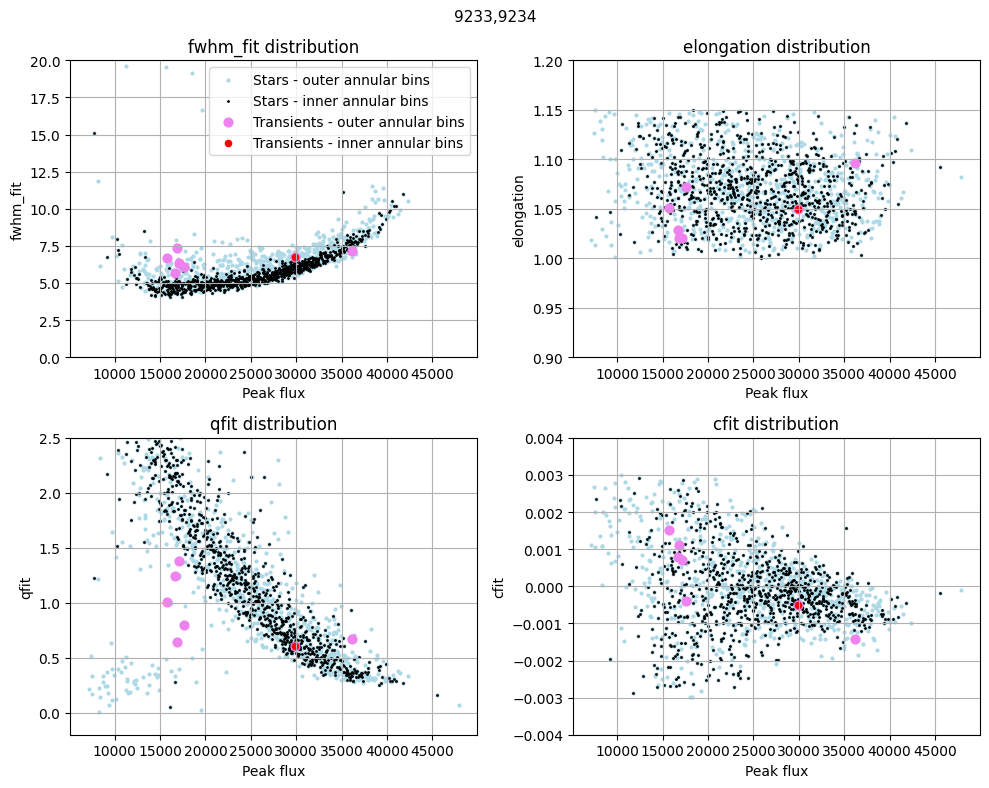

36167.3359375 7.176115196113687 40348300057199
29910.01953125 6.742963493207455 40348300096763
17597.498046875 6.099464184831533 40348300111272
17070.373046875 6.326722650950296 40348300105176
16846.072265625 7.339306331331373 40348300099413
16694.98046875 5.698797249819094 40348300111246
15727.439453125 6.691334497054435 40348300068413




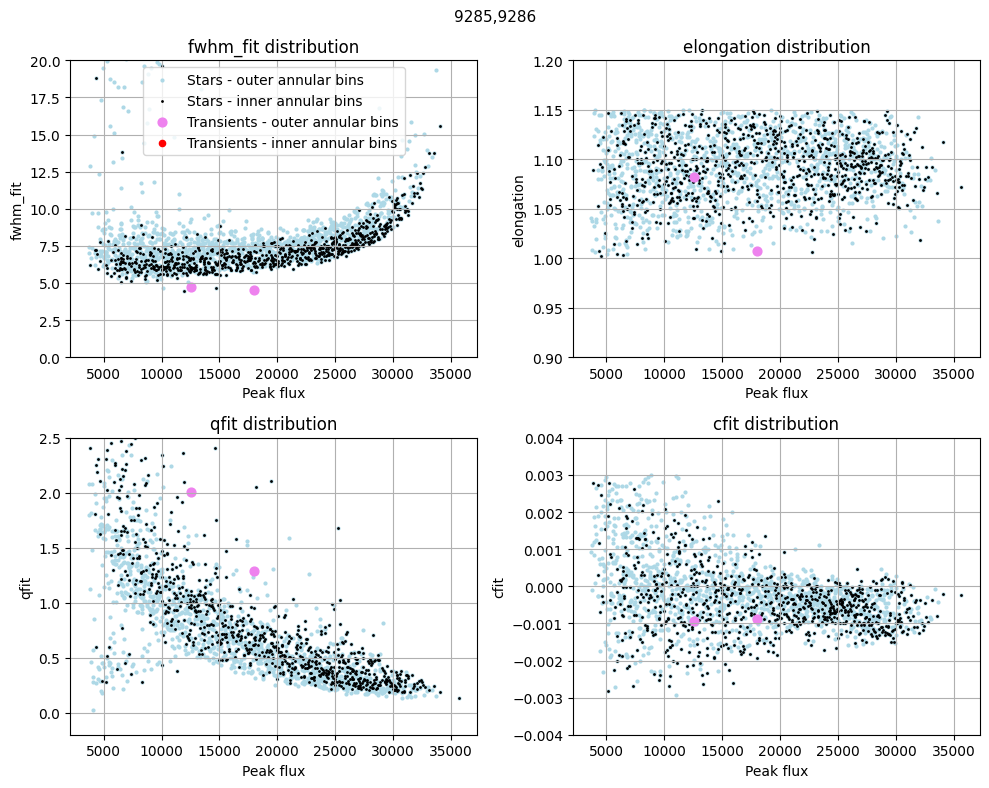

18026.234375 4.561112311608651 40349040160435
12580.6513671875 4.715789823617486 40349040003448




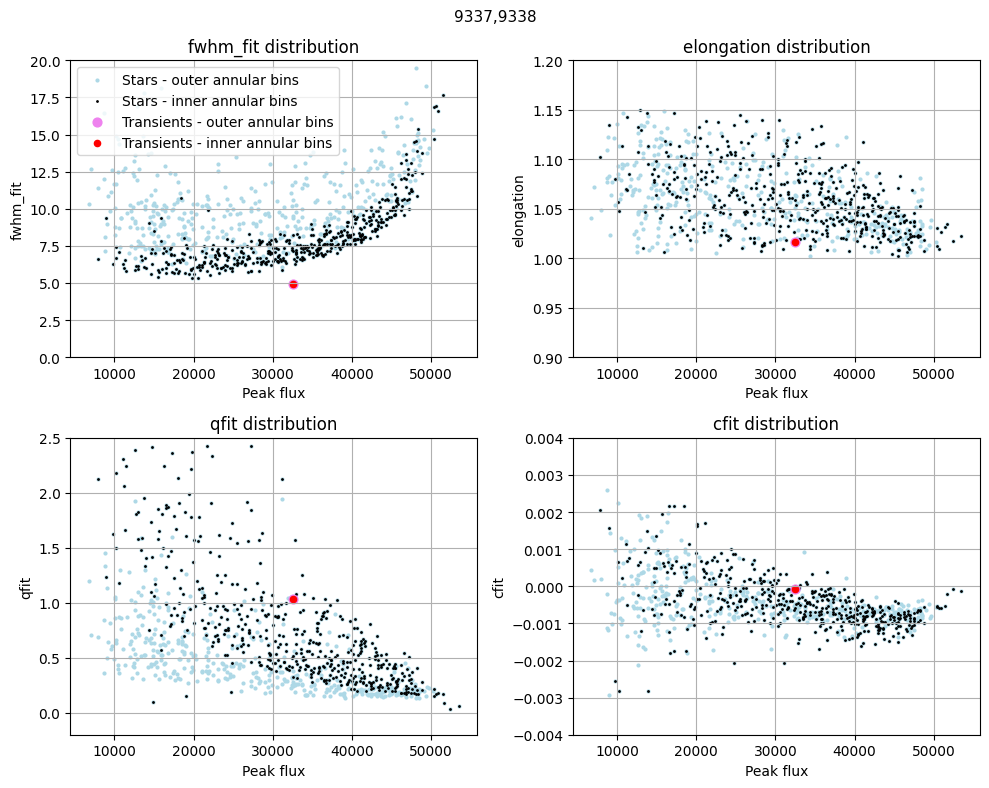

32500.4765625 4.96598609942658 40349850006415




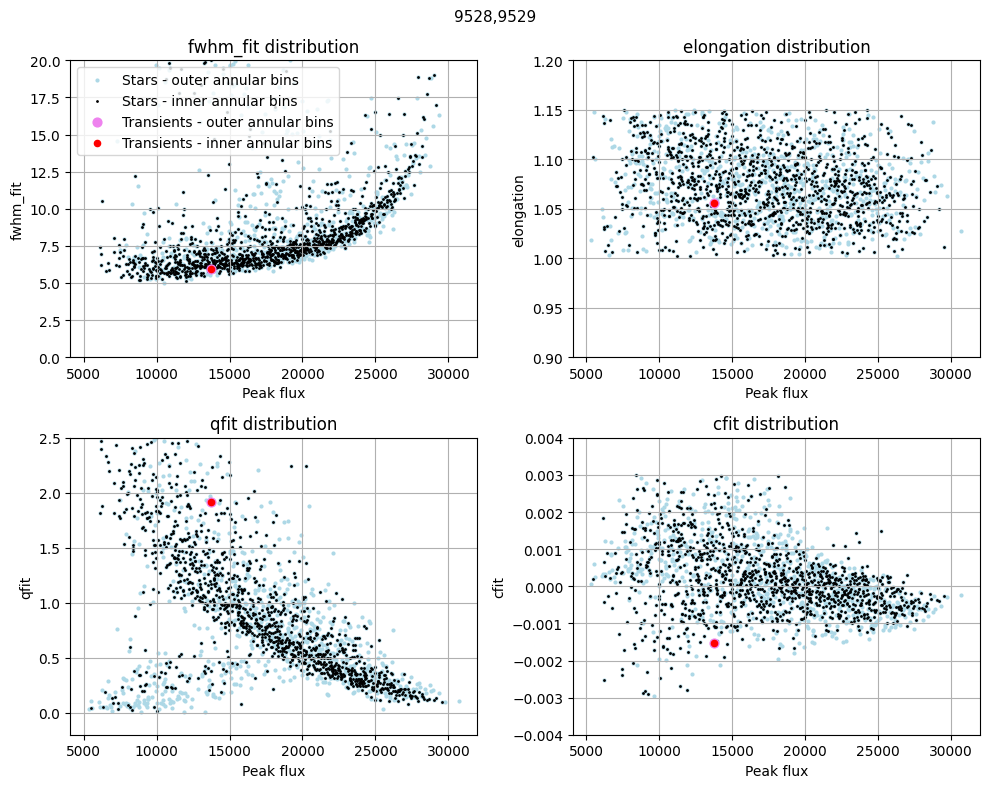

13749.76953125 5.921769866545138 40351260186710




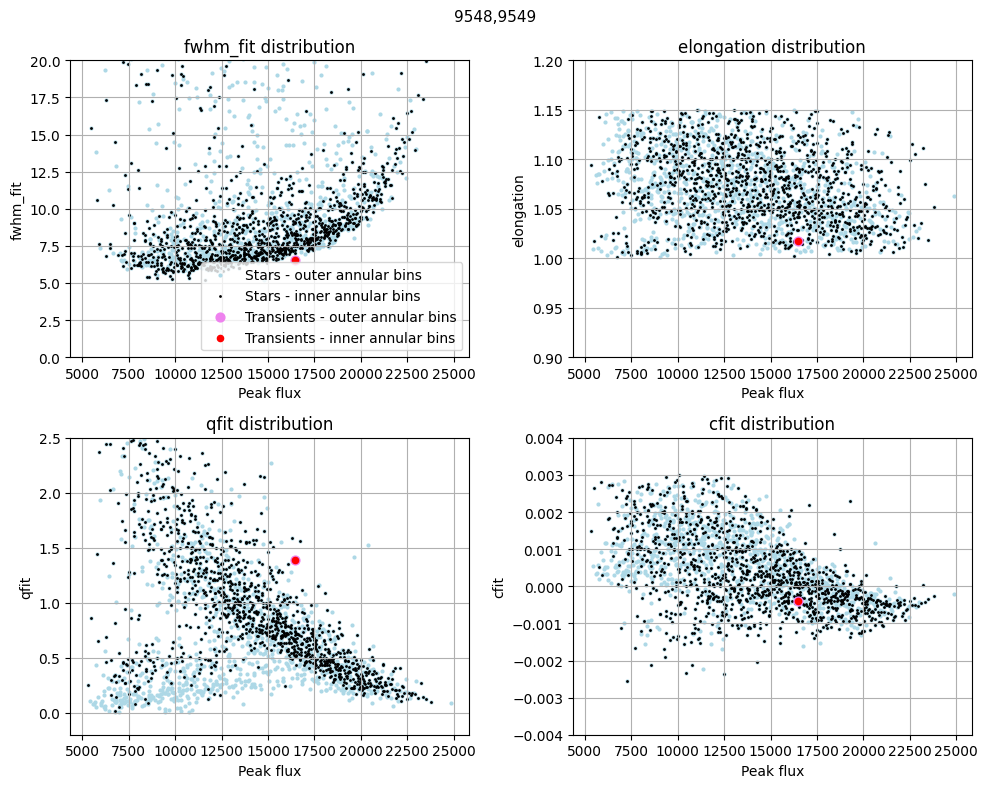

16465.955078125 6.519942820824448 40351580164385




In [9]:
for plate_id in list(counter.keys()):

    # isolate rows for selected plate
    mask = table_transients['plate_id_1'] == plate_id
    table_plate = table_transients[mask]

    par, dataset_key = get_par(table_plate)

    # finally, get table with star data    
    table_reference  = Table.read(fname(par['table_psf_matched']), format='fits')
    
    # now, it's time to plot
    _ = plot_psf_analysis([table_reference, table_plate], par, title=dataset_key,
                      labels=[['Stars - outer annular bins', 'Stars - inner annular bins'], 
                              ['Transients - outer annular bins', 'Transients - inner annular bins']],
                       sizes = [[4, 1], [40, 20]])

    for row in range(len(table_plate)):
        print(table_plate['flux_max'][row], table_plate['fwhm_fit'][row], table_plate['source_id'][row])
    print()
    print()

### Discussion:

One can see many transients that have a smaller FWHM than stars of same brightness. Their shapes (qfit) tend to depart from a Gaussian more than a typical star image does. 

The narrower, the more they depart from the qfit=0 locus. There are quite a few counterexamples in several plates, where transients have FWHM values indistinguishable from stars, and also shapes closer to Gaussian.

So, maybe we are facing two classes of objects? One of them might be just plate artifacts not yet accounted for? It would be informative to segregate objects in these two classes based on the diagrams above, and then look at their images on the sky.

**Note**: the systematic difference seen in stars at inner and outer annular bins (Applause concept to measure distance to center of plate) is caused by slight defocussing (likely the glass plate was not bent to the exact shape of the focal surface). The effect can be seen very clearly in a few plates, in which the analysis included only the more central annular bins ("inner" and "outer" mean the inner and outer half of the range of annular bins actually included in the analysis).




Lets separate the two cases mentioned above:

- transient FWHM visibly smaller than star's
- transient FWHM similar to star's

### Two populations?

Based on the plots and data printed above, we create by hand a data structure that discriminates the two separate cases. 

In [10]:
# This dict establishes the connections between source IDs, plates, and the
# two categories of FWHM behaviors that we observe in transients. The two
# categories are based on how the transient FWHM compares with the FWHM of
# stars of similar magnitude, on any given plate. The first case includes
# transients that are narrower than star's, the second case includes 
# transients that have similar, or even larger widths, than stars.
linewidths = {
    'small_fwhm': {
        '9246': [40348560131057, 40348560185546, 40348560141104],
        '9016': [40346780012245],
        '9095': [40347080017951, 40347080034555, 40347080035033,
                 40347080009365, 40347080006016, 40347080009636],
        '9099': [40347160060262, 40347160009515, 40347160043802, 
                 40347160024138, 40347160015446, 40347160028698],
        '9174': [40347800283769],
        '9228': [40348200158428],
        '9285': [40349040160435, 40349040003448],
        '9337': [40349850006415],
        '9533': [40351330140141],
        '9548': [40351580164385],
    },
    'stellar_fwhm': {
        '9228': [40348200090053],
        '9246': [40348560212653],
        '9319': [40349380007658],
        '9322': [40349440012079],
        '9545': [40351520017054],
        '9012': [40346700054403, 40346700056383],
        '9095': [40347080008013, 40347080020371, 40347080014373,
                 40347080013570, 40347080039830, 40347080018409,
                 40347080018721, 40347080029335, 40347080031873, 
                 40347080012953, 40347080008041, 40347080018531,
                 40347080036412, 40347080006319, 40347080014630,
                 40347080023887, 40347080027642, 40347080014828,
                 40347080026234],
        '9099': [40347160011655, 40347160046861, 40347160023829,
                 40347160024335, 40347160034420, 40347160023280,
                 40347160038529, 40347160056784, 40347160020302],
        '9233': [40348300057199, 40348300096763, 40348300111272,
                 40348300105176, 40348300099413, 40348300111246,
                 40348300068413],
        '9528': [40351260186710],
    },
}

There are 23 transients in the narrow FWHM group, and 43 in the stellar FWHM group.

Note that 40 out of the 63 total transients come from just two plates, 9095 and 9099, both obtained on the first week of April 1956. One could think that they are indeed plate defects caused by some bad batch of plates or developing chemicals used in that week, for instance. Or, that the skies swarmed with sources of light. A search of the logbooks and logpages in Applause might be worth the trouble. 

We should now look at the transients themselves, with plots grouped together by type.

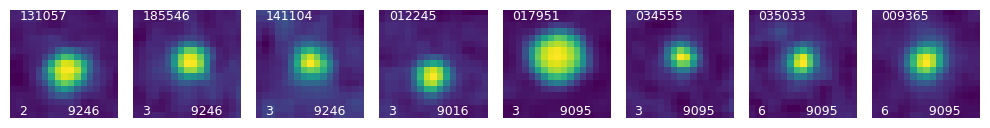

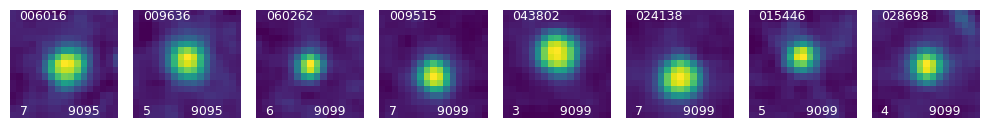

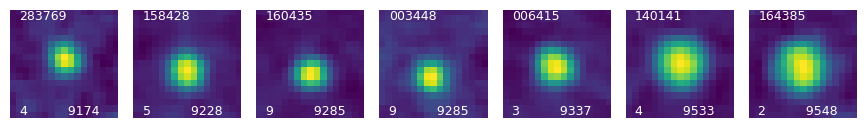

----------------------------------------------------------------------


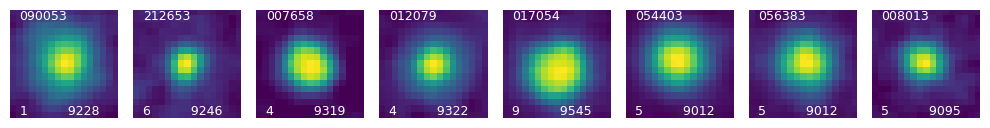

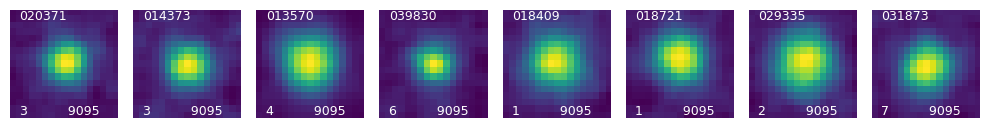

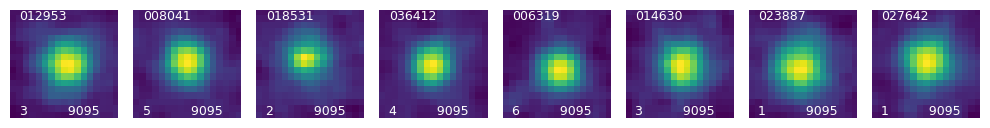

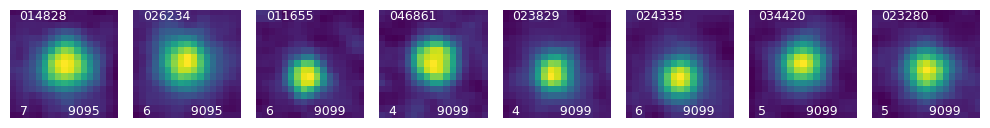

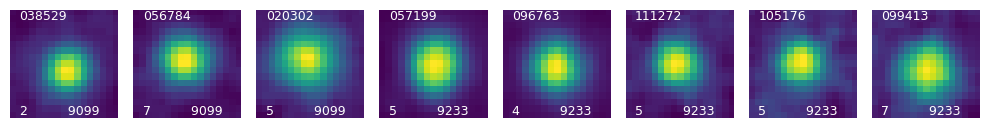

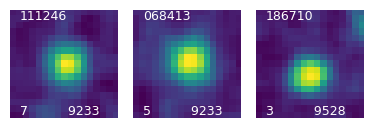

In [11]:
plates = linewidths['small_fwhm']
plot_cutout_series(plates, table_transients, images, None)
print('----------------------------------------------------------------------')
plates = linewidths['stellar_fwhm']
plot_cutout_series(plates, table_transients, images, None)

The first set above contains the narrow transients; the second set, the transients with widths indistinguishable from stars in the same plate, with same brightness. The *qfit* plots at the top of the PSF section also tell us that transients in the second set have shapes closer to a Gaussian shape, than transients in the first set (although both transients *and* stars have somewhat non-Gaussian shapes, with the difference from a Gaussian being dependent on brightness - an expected outcome given the non-linearity of photographic plates).

The numbers in each plot are:

- **top**: source ID

- **bottom left**: the *annular_bin* where the transient is found on the plate. That's an APPLAUSE concept that encodes the distance from the plate center, 1 being closest to the center, up to 9 at the edge. Because at the edge the camera focus can be a little off, and because there is evidence (cite?) that plate edges tend to hold more artifacts, we can use it to help in telling apart "true" transients from artifacts. 

- **bottom right**: plate Id

I cannot see any significant difference in between the two groups, aside from the (expected) fact that the second group has in general fuzzier images with more of an extended halo. A few cases seem to suggest an asymetry in the central region, but examining them against similar plots of stars in the neighborhood, it is difficult to reject them based solely on that impression.

For comparison with actual star images, the pipeline output files in subdirectory *results/* show similar thumbnail images for each comparison star used with each transient.  